In [15]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.stats import chi2_contingency

1. Загружаем данные
2. Создаем колонку с категорией для каждого датасета 
3. Объединяем всё в один большой датафрейм

In [2]:
df_food = pd.read_excel('wb_food.xlsx')
df_cosmetics = pd.read_excel('wb_cosmetics.xlsx') 
df_chemistry = pd.read_excel('wb_chemistry.xlsx')

df_food['category'] = 'food'
df_cosmetics['category'] = 'cosmetics'
df_chemistry['category'] = 'chemistry'

df = pd.concat([df_food, df_cosmetics, df_chemistry], ignore_index=True)

print(df.head())

                                                name    price rating  \
0  / Готовый завтрак Хрустлайт клубника со сливка...    196 ₽    4,9   
1  / Программа питания для похудения жиросжигател...  1 509 ₽    4,7   
2  / Каша овсяная STEEL CUT OATS овес резаный Мюл...    105 ₽    4,9   
3             / Крахмал кукурузный без глютена 200 г     60 ₽      5   
4             / Лук жареный хрустящий сушеный 470 гр    347 ₽    4,9   

           marks                brand category  
0   2 007 оценок  Сибирская клетчатка     food  
1   3 606 оценок               ЛЕОВИТ     food  
2  37 488 оценок         Myllyn Paras     food  
3   6 794 оценки               Гарнец     food  
4  20 721 оценка              Эндакси     food  


Предобработка данных

1. Очистка цены
2. Очистка рейтинга 
3. Очистка количества оценок
4. Создание переменной этичности

In [3]:
df['price'] = df['price'].astype(str).str.replace(r'[^\d]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['rating'] = df['rating'].astype(str).str.replace(',', '.')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['marks'] = df['marks'].astype(str).str.replace(r'[^\d]', '', regex=True)
df['marks'] = pd.to_numeric(df['marks'], errors='coerce')

ethical_keywords = ['эко', 'био', 'органик', 'eco', 'organic', 'bio']
pattern = '|'.join(ethical_keywords)
df['is_ethical'] = df['name'].str.lower().str.contains(pattern, case=False, na=False).astype(int)

print(df[['price', 'rating', 'marks']].isna().sum())

price       0
rating    388
marks     388
dtype: int64


Настраиваем фильтр для поиска этичных товаров (ищем не только в названии, но и в бренде)

In [4]:
extended_keywords = [
    r'\bэко', r'\beco', r'\bесо', 
    r'\bбио', r'\bbio', 
    'органик', 'organic',
    'натуральн', 'natural', 'nature', 'растительн', 'plant', 'botanical',
    'фермерск', 'ремеслен', 'craft', 
    'веган', 'vegan', 'зож', 'без гмо', 'non-gmo', 'пп', 'суперфуд', 'raw', 'сыроед',
    'без сульфатов', 'без парабенов', 'sls free', 'paraben free', 'sulfate free',
    'гипоаллерген', 'hypoallergenic', 'дерматологически', 
    'cruelty free', 'не тестир', 'биоразлагаем', 'biodegradable', 
    'eco-friendly', 'перерабатываем', 'recycled', 'zero waste'
]

pattern = '|'.join(extended_keywords)

df['is_ethical'] = (
    df['name'].astype(str).str.lower().str.contains(pattern, case=False, na=False) |
    df['brand'].astype(str).str.lower().str.contains(pattern, case=False, na=False)
).astype(int)

total_ethical = df['is_ethical'].sum()
percent_ethical = (total_ethical / len(df)) * 100

print(f"Поиск нашел товаров: {total_ethical} ({percent_ethical:.1f}% от всей выборки)")
print("Распределение по категориям:")
print(df.groupby('category')['is_ethical'].sum())

Поиск нашел товаров: 166 (4.8% от всей выборки)
Распределение по категориям:
category
chemistry    32
cosmetics    38
food         96
Name: is_ethical, dtype: int64


Проверка гипотезы H2

1. Разделяем рейтинги этичных и обычных товаров, удаляя пустые значения
2. Используем U-критерий Манна-Уитни

In [5]:
ratings_ethical = df[df['is_ethical'] == 1]['rating'].dropna()
ratings_standard = df[df['is_ethical'] == 0]['rating'].dropna()

print(f"Средний рейтинг этичных: {ratings_ethical.mean():.2f}")
print(f"Средний рейтинг обычных: {ratings_standard.mean():.2f}")

stat, p_value = stats.mannwhitneyu(ratings_ethical, ratings_standard, alternative='two-sided')
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Вывод по H2: Рейтинги статистически значимо различаются. Гипотеза Н2 ОТВЕРГАЕТСЯ (или подтверждается, в зависимости от того, кто выше).")
else:
    print("Вывод по H2: Статистически значимой разницы в рейтингах НЕТ. Гипотеза Н2 ПОДТВЕРЖДАЕТСЯ (потребители не ставят этичным товарам оценки выше, что бьется с теорией гринвошинга).")


Средний рейтинг этичных: 4.86
Средний рейтинг обычных: 4.86
p-value: 0.4896
Вывод по H2: Статистически значимой разницы в рейтингах НЕТ. Гипотеза Н2 ПОДТВЕРЖДАЕТСЯ (потребители не ставят этичным товарам оценки выше, что бьется с теорией гринвошинга).


Проверка гипотез H1 и H3 (эконометрический анализ)

1. Создание логарифмических переменных для всего датасета
2. Создание регрессий для каждой категории 

In [6]:
df['ln_price'] = np.log(df['price'])
df['ln_marks'] = np.log(df['marks'] + 1) 

df_food = df[df['category'] == 'food']
model_food = smf.ols("ln_price ~ is_ethical + rating + ln_marks", data=df_food).fit(cov_type='HC3')
print(model_food.summary())

df_cosmetics = df[df['category'] == 'cosmetics']
model_cosmetics = smf.ols("ln_price ~ is_ethical + rating + ln_marks", data=df_cosmetics).fit(cov_type='HC3')
print(model_cosmetics.summary())

df_chemistry = df[df['category'] == 'chemistry']
model_chemistry = smf.ols("ln_price ~ is_ethical + rating + ln_marks", data=df_chemistry).fit(cov_type='HC3')
print(model_chemistry.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     3172.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:31:03   Log-Likelihood:                -1300.2
No. Observations:                1440   AIC:                             2608.
Df Residuals:                    1436   BIC:                             2630.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     51.4611      0.475    108.445      0.0

Тест Хи-квадрат для проверки H3

In [19]:
df['is_perfect'] = (df['rating'] == 5.0).astype(int)
categories = ['food', 'cosmetics', 'chemistry']

for cat in categories:
    sub_df = df[df['category'] == cat]
    crosstab_count = pd.crosstab(
        index=sub_df['is_ethical'].replace({0: 'Стандартные', 1: 'Этичные'}),
        columns=sub_df['is_perfect'].replace({0: '< 5.0 (С изъяном)', 1: '5.0 (Идеал)'}),
        margins=True, 
        margins_name="Всего"
    )
    
    crosstab_pct = pd.crosstab(
        index=sub_df['is_ethical'].replace({0: 'Стандартные', 1: 'Этичные'}),
        columns=sub_df['is_perfect'].replace({0: '< 5.0', 1: '5.0 (Идеал)'}),
        normalize='index' 
    ) * 100

    chi2, p_val, dof, expected = chi2_contingency(
        pd.crosstab(sub_df['is_ethical'], sub_df['is_perfect'])
    )
    print(f"результат теста хи-квдрат для категории {cat}:")
    print(f"P-value: {p_val:.4f}")
    if p_val < 0.05:
        print("ВЫВОД: Различия ЗНАЧИМЫ. Маркировка влияет на вероятность получить 5.0")
    else:
        print("ВЫВОД: Различия НЕЗНАЧИМЫ. Маркировка не дает преимущества в оценках")

результат теста хи-квдрат для категории food:
P-value: 0.0000
ВЫВОД: Различия ЗНАЧИМЫ. Маркировка влияет на вероятность получить 5.0
результат теста хи-квдрат для категории cosmetics:
P-value: 1.0000
ВЫВОД: Различия НЕЗНАЧИМЫ. Маркировка не дает преимущества в оценках
результат теста хи-квдрат для категории chemistry:
P-value: 0.8376
ВЫВОД: Различия НЕЗНАЧИМЫ. Маркировка не дает преимущества в оценках


Визуализации

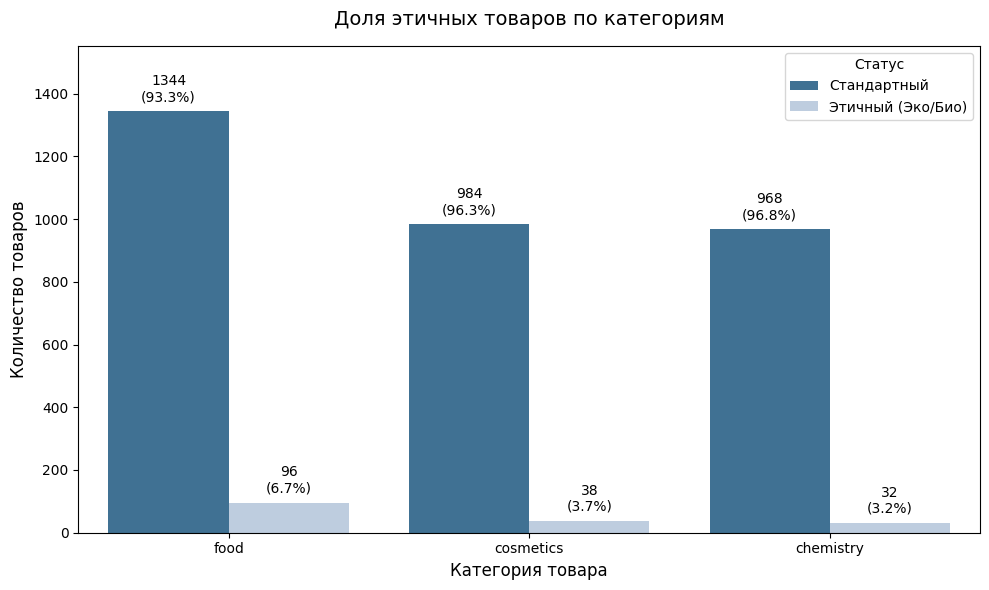

In [9]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df, 
    x='category', 
    hue='is_ethical',
    palette=['#3274a1', '#b8cce4'] 
)

plt.title('Доля этичных товаров по категориям', fontsize=14, pad=15)
plt.xlabel('Категория товара', fontsize=12)
plt.ylabel('Количество товаров', fontsize=12)

plt.legend(title='Статус', labels=['Стандартный', 'Этичный (Эко/Био)'])

category_totals = df['category'].value_counts()
for p in ax.patches:
    height = p.get_height()
    if pd.isna(height) or height == 0:
        continue
    cat_index = int(round(p.get_x())) 
    cat_name = ax.get_xticklabels()[cat_index].get_text()
    total_in_cat = category_totals[cat_name]
    percentage = (height / total_in_cat) * 100
    text_label = f'{int(height)}\n({percentage:.1f}%)'
    ax.annotate(text_label, 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom',                 
                fontsize=10, 
                xytext=(0, 5),                           
                textcoords='offset points')

plt.ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

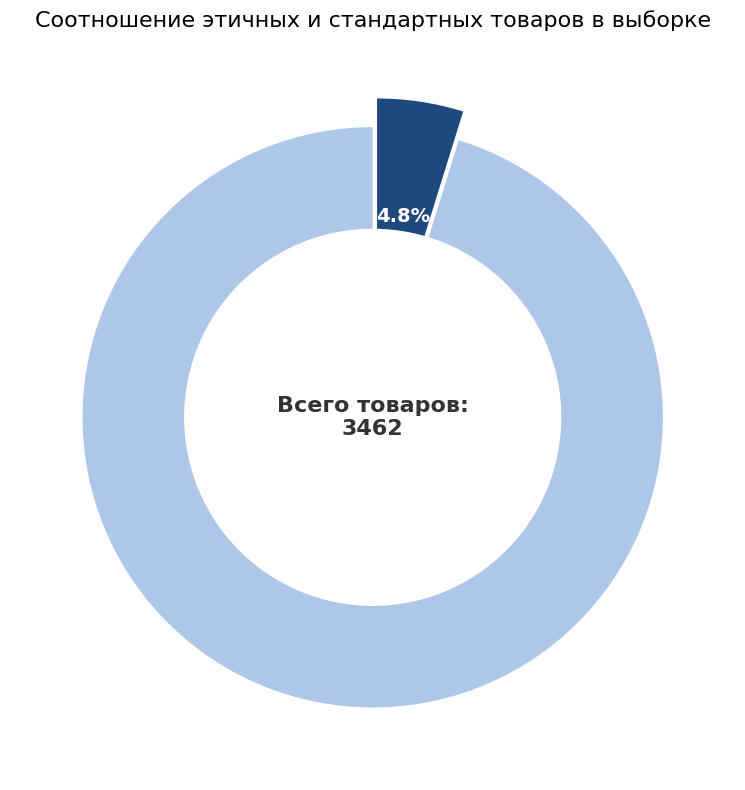

In [10]:
ethical_count = df['is_ethical'].sum()
standard_count = len(df) - ethical_count

labels = ['Стандартные товары', 'Товары с эко-маркировкой']
sizes = [standard_count, ethical_count]
colors = ['#aec7e8', '#1f497d']
explode = (0, 0.1)

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors, 
                                  autopct='%1.1f%%', startangle=90, 
                                  textprops=dict(color="white", fontsize=14))

centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig.gca().add_artist(centre_circle)

plt.setp(autotexts, size=14, weight="bold")
plt.title('Соотношение этичных и стандартных товаров в выборке', fontsize=16, pad=20)
total_text = f'Всего товаров:\n{len(df)}'
plt.text(0, 0, total_text, ha='center', va='center', fontsize=16, weight='bold', color='#333333')

plt.tight_layout()
plt.show()

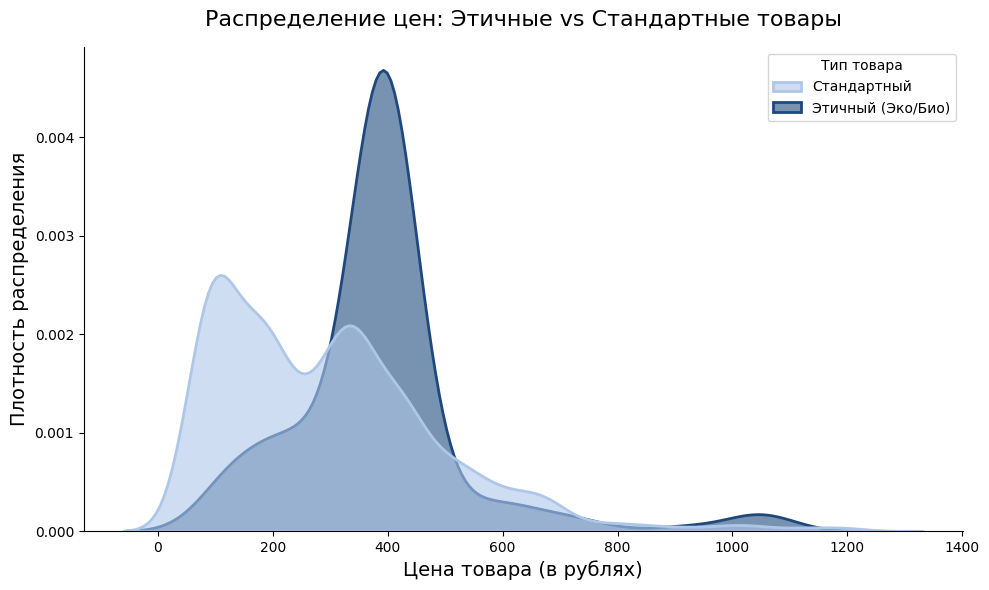

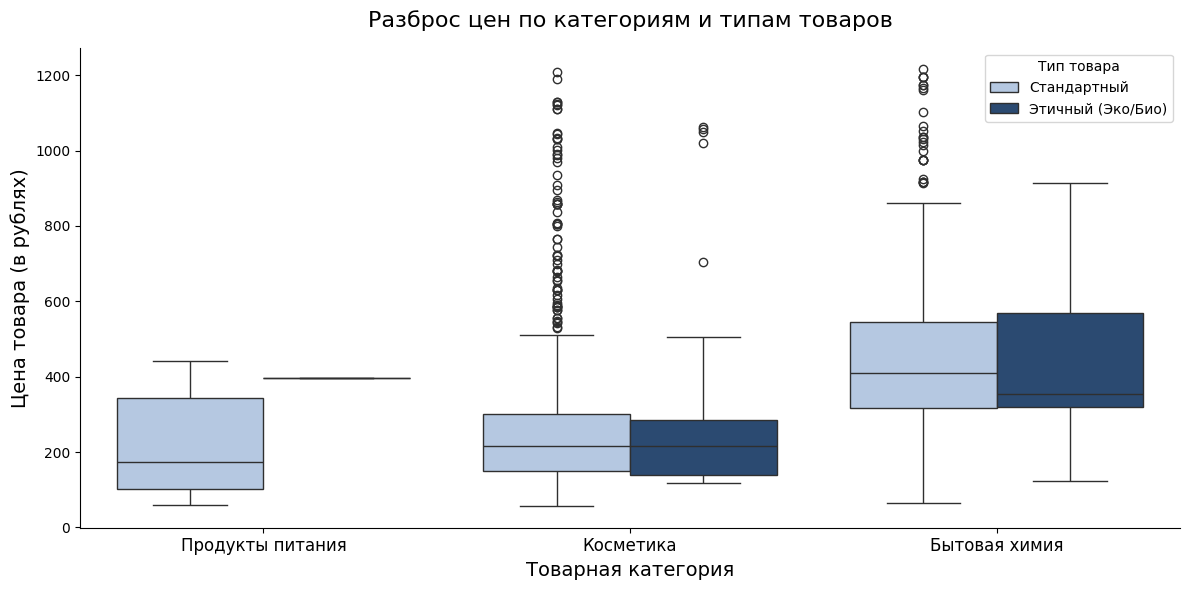

In [11]:
df_clean = df.dropna(subset=['price']).copy()
threshold = df_clean['price'].quantile(0.95) 
df_plot = df_clean[df_clean['price'] < threshold].copy()
df_plot['Тип товара'] = df_plot['is_ethical'].map({0: 'Стандартный', 1: 'Этичный (Эко/Био)'})
palette_colors = {'Стандартный': '#aec7e8', 'Этичный (Эко/Био)': '#1f497d'}


#ГРАФИК 1: График плотности распределения
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_plot, x='price', hue='Тип товара', fill=True,
            common_norm=False, palette=palette_colors, alpha=0.6, linewidth=2)

plt.title('Распределение цен: Этичные vs Стандартные товары', fontsize=16, pad=15)
plt.xlabel('Цена товара (в рублях)', fontsize=14)
plt.ylabel('Плотность распределения', fontsize=14)
sns.despine() 
plt.tight_layout()
plt.show()


# ГРАФИК 2: Ящик с усами в разрезе категорий
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='category', y='price', hue='Тип товара', palette=palette_colors)

plt.title('Разброс цен по категориям и типам товаров', fontsize=16, pad=15)
plt.xlabel('Товарная категория', fontsize=14)
plt.ylabel('Цена товара (в рублях)', fontsize=14)

plt.xticks(ticks=[0, 1, 2], labels=['Продукты питания', 'Косметика', 'Бытовая химия'], fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

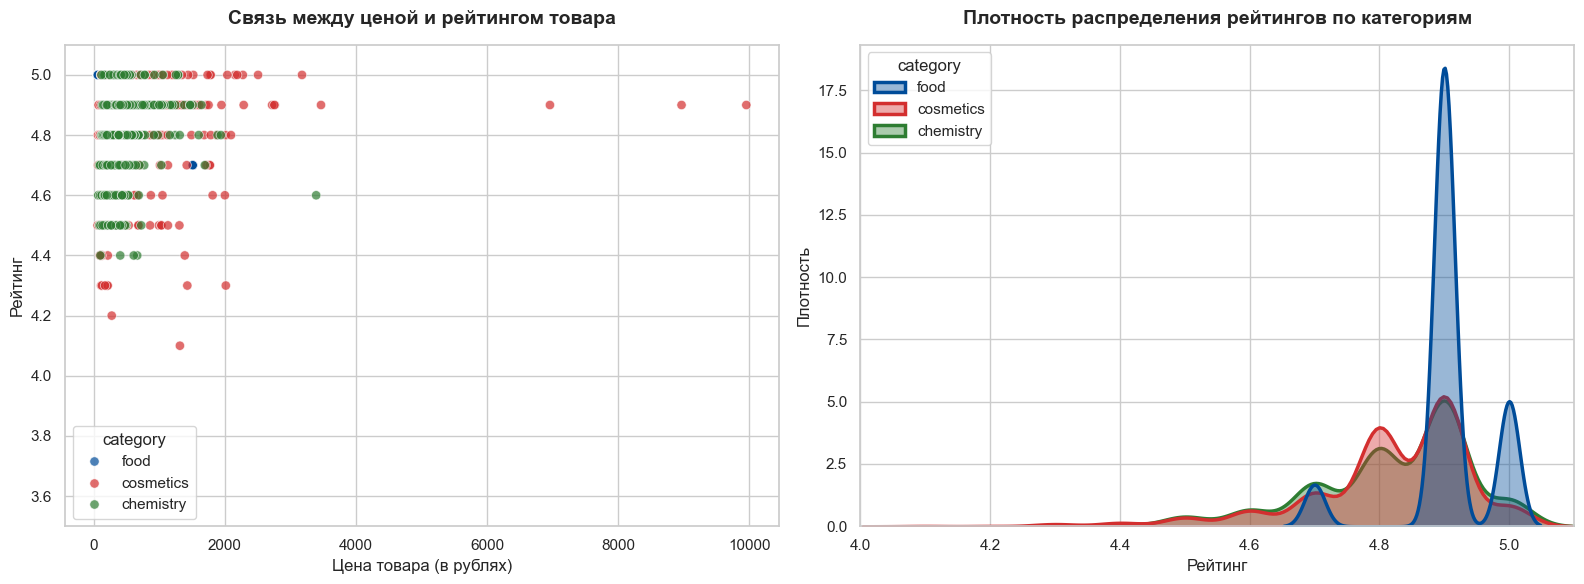

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
my_palette = {'food': '#004C99', 'cosmetics': '#D32F2F', 'chemistry': '#2E7D32'}

# ГРАФИК 1: Зависимость рейтинга от цены
sns.scatterplot(
    data=df, 
    x='price', 
    y='rating', 
    hue='category',
    palette=my_palette,
    alpha=0.7,          
    s=45,               
    edgecolor='white',  
    ax=axes[0]
)
axes[0].set_title('Связь между ценой и рейтингом товара', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Цена товара (в рублях)', fontsize=12)
axes[0].set_ylabel('Рейтинг', fontsize=12)
axes[0].set_ylim(3.5, 5.1) 

# ГРАФИК 2: Распределение рейтингов по категориям
sns.kdeplot(
    data=df, 
    x='rating', 
    hue='category', 
    palette=my_palette,
    fill=True,
    common_norm=False,
    alpha=0.4,          
    linewidth=2.5,      
    ax=axes[1]
)
axes[1].set_title('Плотность распределения рейтингов по категориям', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Рейтинг', fontsize=12)
axes[1].set_ylabel('Плотность', fontsize=12)
axes[1].set_xlim(4.0, 5.1)

plt.tight_layout()
plt.show()

C:\Users\Марина\AppData\Local\Temp\ipykernel_18904\2103771651.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\Марина\AppData\Local\Temp\ipykernel_18904\2103771651.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Стандартные', 'Этичные'])


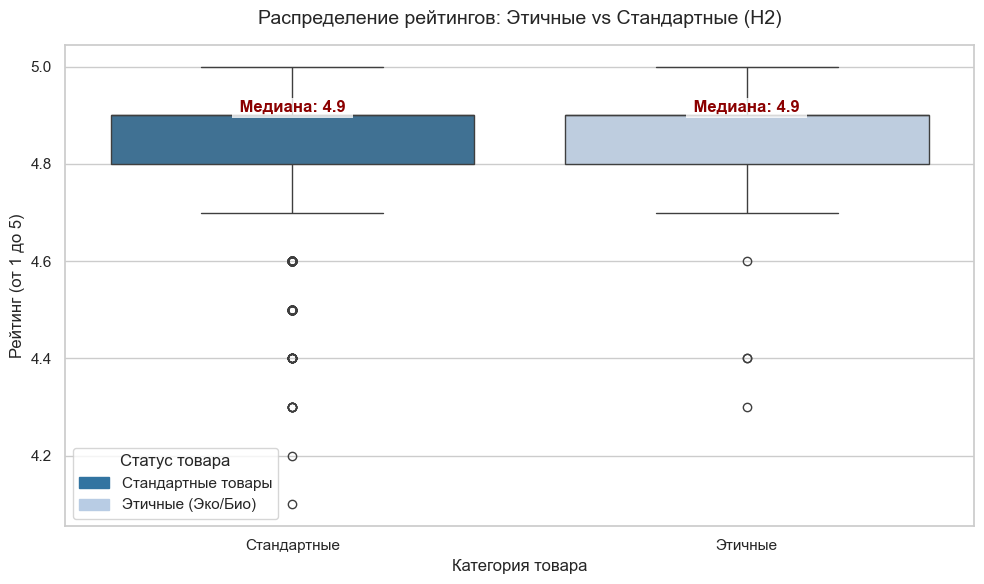

In [ ]:
plt.figure(figsize=(10, 6))

colors = ['#3274a1', '#b8cce4']

ax = sns.boxplot(
    data=df, 
    x='is_ethical', 
    y='rating', 
    palette=colors
)

plt.title('Распределение рейтингов: Этичные vs Стандартные (H2)', fontsize=14, pad=15)
plt.ylabel('Рейтинг (от 1 до 5)', fontsize=12)
plt.xlabel('Категория товара', fontsize=12)

patch_standard = mpatches.Patch(color=colors[0], label='Стандартные товары')
patch_ethical = mpatches.Patch(color=colors[1], label='Этичные (Эко/Био)')
plt.legend(handles=[patch_standard, patch_ethical], title="Статус товара", fontsize=11)

ax.set_xticklabels(['Стандартные', 'Этичные'])
medians = df.groupby('is_ethical')['rating'].median()
for i, tick in enumerate(ax.get_xticks()):
    median_val = medians.iloc[i]
    ax.text(
        tick, 
        median_val, 
        f' Медиана: {median_val} ', 
        horizontalalignment='center', 
        verticalalignment='bottom',   
        fontsize=12,
        fontweight='bold',
        color='#8b0000', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2) 
    )

plt.tight_layout()
plt.show()

C:\Users\Марина\AppData\Local\Temp\ipykernel_2272\4198781042.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


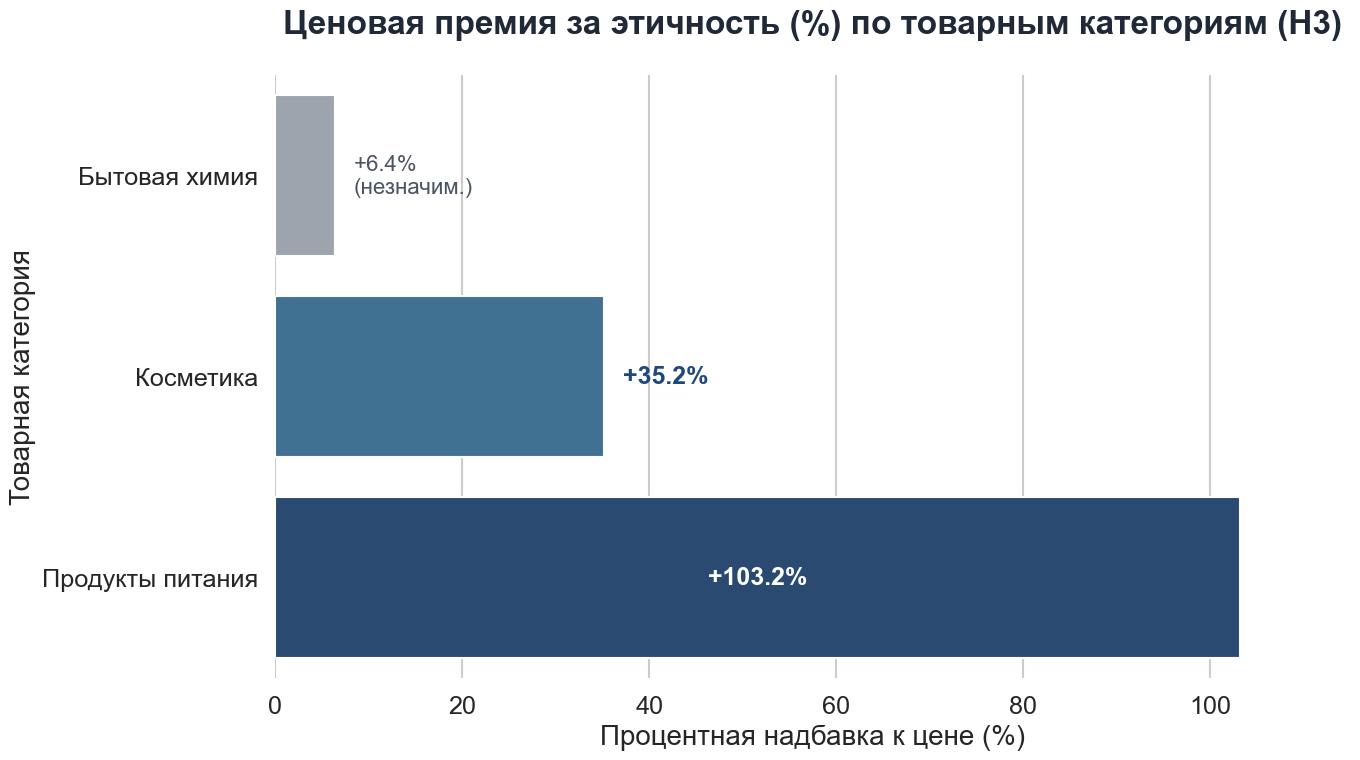

In [16]:
categories_rus = ['Бытовая химия', 'Косметика', 'Продукты питания']
premiums = [6.4, 35.2, 103.2] 
significance = [False, True, True] 

plot_data = pd.DataFrame({
    'Category': categories_rus,
    'Premium': premiums,
    'Significant': significance
})

plot_data = plot_data.sort_values(by='Premium', ascending=True)


sns.set_theme(style="whitegrid", context="talk", font_scale=1.1)
colors_sorted = []
for sig, prem in zip(plot_data['Significant'], plot_data['Premium']):
    if sig and prem > 50: 
        colors_sorted.append('#1f497d')
    elif sig: 
        colors_sorted.append('#3274a1') 
    else: 
        colors_sorted.append('#9ca3af') 

fig, ax = plt.subplots(figsize=(14, 8))

barplot = sns.barplot(
    x='Premium',
    y='Category',
    data=plot_data,
    palette=colors_sorted,
    ax=ax
)

ax.set_title('Ценовая премия за этичность (%) по товарным категориям (H3)', fontsize=24, fontweight='bold', pad=30, color='#1f2937')
ax.set_xlabel('Процентная надбавка к цене (%)', fontsize=20)
ax.set_ylabel('Товарная категория', fontsize=20)
ax.set_xlim(0, 115) 
sns.despine(left=True, bottom=True)

for i, p in enumerate(barplot.patches):
    width = p.get_width() 
    y_pos = p.get_y() + p.get_height() / 2 
    label_text = f"+{width:.1f}%"
    label_fontweight = 'normal'
    current_sig = plot_data.iloc[i]['Significant']

    if not current_sig:
        label_text += "\n(незначим.)"
        label_color = '#4b5563' 
        ax.text(width + 2, y_pos, label_text, ha='left', va='center', fontsize=16, color=label_color)

    elif current_sig and width > 50:
         label_text = f"+{width:.1f}%"
         ax.text(width / 2, y_pos, label_text, ha='center', va='center', fontsize=18, fontweight='bold', color='white')

    else:
         label_text = f"+{width:.1f}%"
         ax.text(width + 2, y_pos, label_text, ha='left', va='center', fontsize=18, fontweight='bold', color='#1f497d')

plt.tight_layout()
plt.show()

   Категория  Стандартные (%)  Этичные (%)  p-value Значимость
0       food             21.4          0.0   0.0000    Значимо
1  cosmetics              6.4          5.3   1.0000  Незначимо
2  chemistry              5.6          3.1   0.8376  Незначимо


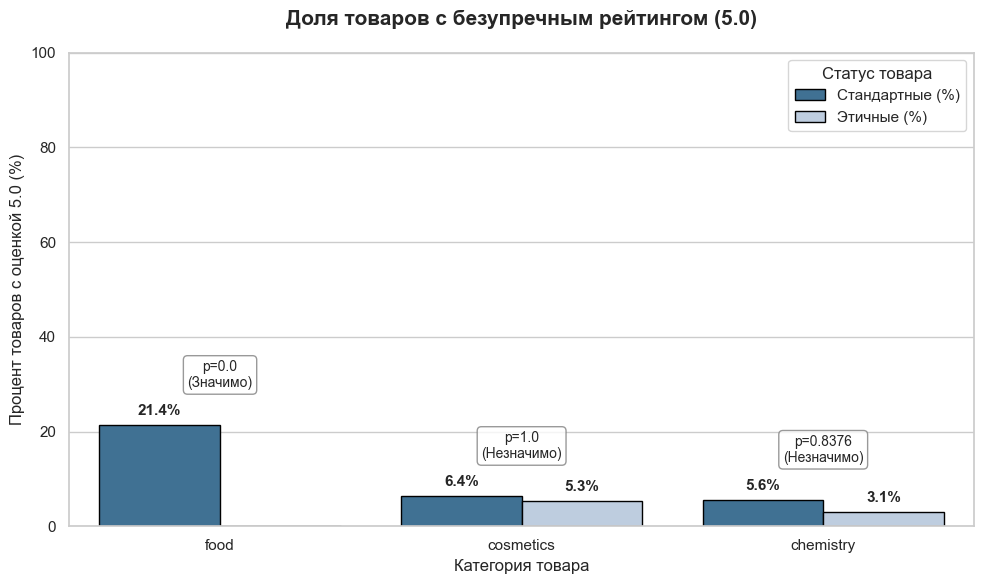

In [17]:
df['is_perfect'] = (df['rating'] == 5.0).astype(int)
categories = ['food', 'cosmetics', 'chemistry']
results = []

for cat in categories:
    sub_df = df[df['category'] == cat]
    share_std = sub_df[sub_df['is_ethical'] == 0]['is_perfect'].mean() * 100
    share_eco = sub_df[sub_df['is_ethical'] == 1]['is_perfect'].mean() * 100
    contingency_table = pd.crosstab(sub_df['is_ethical'], sub_df['is_perfect'])
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    
    results.append({
        'Категория': cat,
        'Стандартные (%)': round(share_std, 1),
        'Этичные (%)': round(share_eco, 1),
        'p-value': round(p_val, 4),
        'Значимость': 'Значимо' if p_val < 0.05 else 'Незначимо'
    })

df_results = pd.DataFrame(results)
print(df_results)


df_melted = df_results.melt(id_vars=['Категория', 'p-value', 'Значимость'], 
                            value_vars=['Стандартные (%)', 'Этичные (%)'],
                            var_name='Статус', value_name='Доля идеальных оценок')

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_melted, 
    x='Категория', 
    y='Доля идеальных оценок', 
    hue='Статус',
    palette=['#3274a1', '#b8cce4'],
    edgecolor='black'
)

plt.title('Доля товаров с безупречным рейтингом (5.0)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Процент товаров с оценкой 5.0 (%)', fontsize=12)
plt.xlabel('Категория товара', fontsize=12)
plt.ylim(0, 100)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=11, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

for i, row in df_results.iterrows():
    sig_text = f"p={row['p-value']}\n({row['Значимость']})"
    max_height = max(row['Стандартные (%)'], row['Этичные (%)'])
    plt.text(i, max_height + 8, 
             sig_text, ha='center', fontsize=10, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

plt.legend(title='Статус товара', loc='upper right')
plt.tight_layout()
plt.show()